# MLMC Sample Allocation Strategy Comparison

This notebook investigates different sample allocation strategies for the MLMC framework.

**Structure:**
1. **Part 1:** Effect of varying $C$ in the quadratic formula $M_\ell = C \cdot \dim(V)^2$
2. **Part 2:** True comparison of different allocation formulas (quadratic vs log vs linear vs sqrt)

**Key Questions:**
- Can we reduce samples without losing stability (condition number)?
- Can we reduce samples without losing accuracy?
- What's the computational trade-off?

**Required Files (same folder):**
- `config.py`
- `common.py`
- `mlmc_ot_estimator.py`
- `mlmc_flexible_allocation.py`

**Author:** Wadoud Bouslama  
**Date:** January 2026

## Setup

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd
import time
import warnings
from typing import Callable, Dict, Tuple, List, Union
from dataclasses import dataclass

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# For nicer plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Setup complete!")

Setup complete!


In [34]:
# LOCAL IMPORTS - all files in the same folder
try:
    from config import DEFAULT_PARAMS, ProblemParameters
    print("✓ Imported config.py")
except ImportError as e:
    print(f"✗ Failed to import config.py: {e}")

try:
    from common import VolatilitySurfaceResult
    print("✓ Imported common.py")
except ImportError as e:
    print(f"✗ Failed to import common.py: {e}")

try:
    from mlmc_ot_estimator import (
        estimate_volatility_mlmc,
        tot_degree_poly,
        LevelStats
    )
    print("✓ Imported mlmc_ot_estimator.py")
except ImportError as e:
    print(f"✗ Failed to import mlmc_ot_estimator.py: {e}")

try:
    from mlmc_flexible_allocation import (
        estimate_volatility_mlmc_flexible,
        compute_samples_for_formula,
        ALLOCATION_FORMULAS,
        allocation_quadratic,
        allocation_log,
        allocation_linear,
        allocation_sqrt,
        allocation_log_squared
    )
    print("✓ Imported mlmc_flexible_allocation.py")
    print(f"  Available formulas: {list(ALLOCATION_FORMULAS.keys())}")
except ImportError as e:
    print(f"✗ Failed to import mlmc_flexible_allocation.py: {e}")

✓ Imported config.py
✓ Imported common.py
✓ Imported mlmc_ot_estimator.py
✓ Imported mlmc_flexible_allocation.py
  Available formulas: ['quadratic', 'log', 'linear', 'sqrt', 'log_squared']


In [35]:
# =============================================================================
# STRESS TEST PARAMETER CONFIGURATIONS
# =============================================================================
# Use these to find the limits of the sample allocation strategies.
# Each configuration targets a different stress axis.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. HIGH DIMENSION (more assets = harder regression)
# -----------------------------------------------------------------------------
HIGH_DIM_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.18, 0.15, 0.22, 0.17, 0.19, 0.16, 0.21, 0.14, 0.20]),
    corr_matrix=np.eye(10) * 0.4 + np.ones((10, 10)) * 0.6,  # ρ = 0.6 off-diagonal
    P1=np.ones(10),
    x0=np.ones(10) * 100.0,
    T=0.5,
    K=1000.0,  # Strike scales with number of assets
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 2. HIGH VOLATILITY (larger diffusion = noisier regression)
# -----------------------------------------------------------------------------
HIGH_VOL_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.45, 0.40, 0.50]),  # ~2.5× default volatility
    corr_matrix=np.array([
        [1.0, 0.8, 0.3],
        [0.8, 1.0, 0.1],
        [0.3, 0.1, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 3. HIGH CORRELATION (near-singular covariance structure)
# -----------------------------------------------------------------------------
HIGH_CORR_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.20, 0.20]),
    corr_matrix=np.array([
        [1.00, 0.95, 0.90],
        [0.95, 1.00, 0.92],
        [0.90, 0.92, 1.00]
    ]),  # Very high correlation - nearly collinear assets
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 4. HIGH POLYNOMIAL DEGREE (more basis functions = need more samples)
# -----------------------------------------------------------------------------
HIGH_DEGREE_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.20, 0.15, 0.10]),
    corr_matrix=np.array([
        [1.0, 0.8, 0.3],
        [0.8, 1.0, 0.1],
        [0.3, 0.1, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=0.5,
    K=300.0,
    option_type="put",
    max_degree=5,  # 21 basis functions at Level 0 (vs 10 for degree 3)
    h0=0.025,      # Reduced h0 to avoid Runge phenomenon
    random_seed=42
)

# -----------------------------------------------------------------------------
# 5. VERY HIGH DIMENSION (15 assets - serious curse of dimensionality)
# -----------------------------------------------------------------------------
def make_correlation_matrix(d: int, rho: float) -> np.ndarray:
    """Create valid correlation matrix with constant off-diagonal correlation."""
    return np.eye(d) * (1 - rho) + np.ones((d, d)) * rho

VERY_HIGH_DIM_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.linspace(0.15, 0.25, 15),  # Varying volatilities
    corr_matrix=make_correlation_matrix(15, 0.5),
    P1=np.ones(15),
    x0=np.ones(15) * 100.0,
    T=0.5,
    K=1500.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 6. EXTREME COMBO (high vol + high corr + moderate dimension)
# -----------------------------------------------------------------------------
EXTREME_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.40, 0.45, 0.35, 0.42, 0.38]),
    corr_matrix=np.array([
        [1.00, 0.85, 0.80, 0.75, 0.70],
        [0.85, 1.00, 0.82, 0.78, 0.72],
        [0.80, 0.82, 1.00, 0.80, 0.75],
        [0.75, 0.78, 0.80, 1.00, 0.77],
        [0.70, 0.72, 0.75, 0.77, 1.00]
    ]),
    P1=np.ones(5),
    x0=np.ones(5) * 100.0,
    T=0.5,
    K=500.0,
    option_type="put",
    max_degree=4,  # Higher degree too
    h0=0.035,
    random_seed=42
)

# -----------------------------------------------------------------------------
# 7. LONG MATURITY (more time = wider distribution = harder to fit)
# -----------------------------------------------------------------------------
LONG_MATURITY_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.25, 0.20, 0.22]),
    corr_matrix=np.array([
        [1.0, 0.6, 0.4],
        [0.6, 1.0, 0.5],
        [0.4, 0.5, 1.0]
    ]),
    P1=np.array([1.0, 1.0, 1.0]),
    x0=np.array([100.0, 100.0, 100.0]),
    T=2.0,  # 2 years instead of 6 months
    K=300.0,
    option_type="put",
    max_degree=3,
    h0=0.1,  # Adjusted for longer maturity
    random_seed=42
)

# -----------------------------------------------------------------------------
# 8. MODERATE STRESS (good middle-ground for reliable testing)
# -----------------------------------------------------------------------------
MODERATE_STRESS_PARAMS = ProblemParameters(
    r=0.05,
    sigma=np.array([0.30, 0.25, 0.28, 0.32, 0.27]),
    corr_matrix=make_correlation_matrix(5, 0.7),
    P1=np.ones(5),
    x0=np.ones(5) * 100.0,
    T=0.5,
    K=500.0,
    option_type="put",
    max_degree=3,
    h0=0.05,
    random_seed=42
)

# =============================================================================
# QUICK REFERENCE TABLE
# =============================================================================
#
# | Config                  | d  | σ_avg | ρ_avg | deg | Key Stress Factor      |
# |-------------------------|----| ------|-------|-----|------------------------|
# | DEFAULT_PARAMS          | 3  | 0.15  | 0.4   | 3   | Baseline               |
# | HIGH_DIM_PARAMS         | 10 | 0.18  | 0.6   | 3   | Dimension              |
# | HIGH_VOL_PARAMS         | 3  | 0.45  | 0.4   | 3   | Volatility             |
# | HIGH_CORR_PARAMS        | 3  | 0.20  | 0.92  | 3   | Correlation            |
# | HIGH_DEGREE_PARAMS      | 3  | 0.15  | 0.4   | 5   | Polynomial complexity  |
# | VERY_HIGH_DIM_PARAMS    | 15 | 0.20  | 0.5   | 3   | Severe dimension       |
# | EXTREME_PARAMS          | 5  | 0.40  | 0.77  | 4   | Multi-factor stress    |
# | LONG_MATURITY_PARAMS    | 3  | 0.22  | 0.5   | 3   | Time horizon           |
# | MODERATE_STRESS_PARAMS  | 5  | 0.28  | 0.7   | 3   | Balanced stress test   |
#
# =============================================================================

In [36]:
# Params for testing
params = VERY_HIGH_DIM_PARAMS
print(params)

Problem Parameters (Bayer et al. 2017, Eq. 56)
  Number of assets: d = 15
  Initial prices: x0 = [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100.]
  Initial basket: S0 = 1500.0
  Basket weights: P1 = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

  Risk-free rate: r = 0.05
  Volatilities: σ = [0.15       0.15714286 0.16428571 0.17142857 0.17857143 0.18571429
 0.19285714 0.2        0.20714286 0.21428571 0.22142857 0.22857143
 0.23571429 0.24285714 0.25      ]
  Correlation matrix:
    [1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5 0.5 1.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
    [0.5 0.5 0.5 0.5 0.5

## Helper Functions

In [37]:
def format_samples_table(max_deg: int, strategies: Dict[str, Tuple[int, str]]) -> pd.DataFrame:
    """
    Create a table showing M_l for each strategy and level.
    
    strategies: Dict mapping name -> (C, formula)
    """
    data = []
    for name, (C, formula) in strategies.items():
        samples = compute_samples_for_formula(max_deg, C, formula)
        row = {'Strategy': name, 'C': C, 'Formula': formula}
        total = 0
        for level in range(max_deg + 1):
            row[f'Level {level}'] = samples[level]
            total += samples[level]
        row['Total'] = total
        data.append(row)
    
    return pd.DataFrame(data)


def compute_l2_error(surface1: np.ndarray, surface2: np.ndarray) -> float:
    """Compute relative L² error between two surfaces."""
    diff = surface1 - surface2
    return np.sqrt(np.mean(diff**2)) / np.sqrt(np.mean(surface2**2))


def compute_max_error(surface1: np.ndarray, surface2: np.ndarray) -> float:
    """Compute relative max error between two surfaces."""
    diff = np.abs(surface1 - surface2)
    return np.max(diff) / np.max(np.abs(surface2))

## Define Evaluation Grids

In [38]:
# Evaluation grids
t_grid = np.linspace(0.01, params.T - 0.01, 25)
s_grid = np.linspace(params.S0 * 0.7, params.S0 * 1.3, 30)

print(f"Evaluation grid: {len(t_grid)} × {len(s_grid)} = {len(t_grid) * len(s_grid)} points")
print(f"t range: [{t_grid[0]:.3f}, {t_grid[-1]:.3f}]")
print(f"S range: [{s_grid[0]:.1f}, {s_grid[-1]:.1f}]")

Evaluation grid: 25 × 30 = 750 points
t range: [0.010, 0.490]
S range: [1050.0, 1950.0]


In [39]:
# Experimental settings
N_SEEDS = 10
BASE_SEED = 42

print(f"Each experiment will use {N_SEEDS} random seeds for statistical robustness.")

Each experiment will use 10 random seeds for statistical robustness.


---

# Part 1: Effect of Varying $C$ in the Quadratic Formula

We keep the formula $M_\ell = C \cdot \dim(V)^2$ fixed but vary $C$ across 10 values.

**Goal:** Find the minimum $C$ that maintains numerical stability.

In [40]:
# Values of C to test
C_values = [1, 3, 5, 10, 20, 30, 40, 50, 60, 80, 100, 120, 150]

print("Sample counts for each C value (quadratic formula):")
print("=" * 80)

strategies_C = {f'C={C}': (C, 'quadratic') for C in C_values}
df_C_samples = format_samples_table(params.max_degree, strategies_C)
print(df_C_samples.to_string(index=False))

Sample counts for each C value (quadratic formula):
Strategy   C   Formula  Level 0  Level 1  Level 2  Level 3  Total
     C=1   1 quadratic      100       36        9        1    146
     C=3   3 quadratic      300      108       27        3    438
     C=5   5 quadratic      500      180       45        5    730
    C=10  10 quadratic     1000      360       90       10   1460
    C=20  20 quadratic     2000      720      180       20   2920
    C=30  30 quadratic     3000     1080      270       30   4380
    C=40  40 quadratic     4000     1440      360       40   5840
    C=50  50 quadratic     5000     1800      450       50   7300
    C=60  60 quadratic     6000     2160      540       60   8760
    C=80  80 quadratic     8000     2880      720       80  11680
   C=100 100 quadratic    10000     3600      900      100  14600
   C=120 120 quadratic    12000     4320     1080      120  17520
   C=150 150 quadratic    15000     5400     1350      150  21900


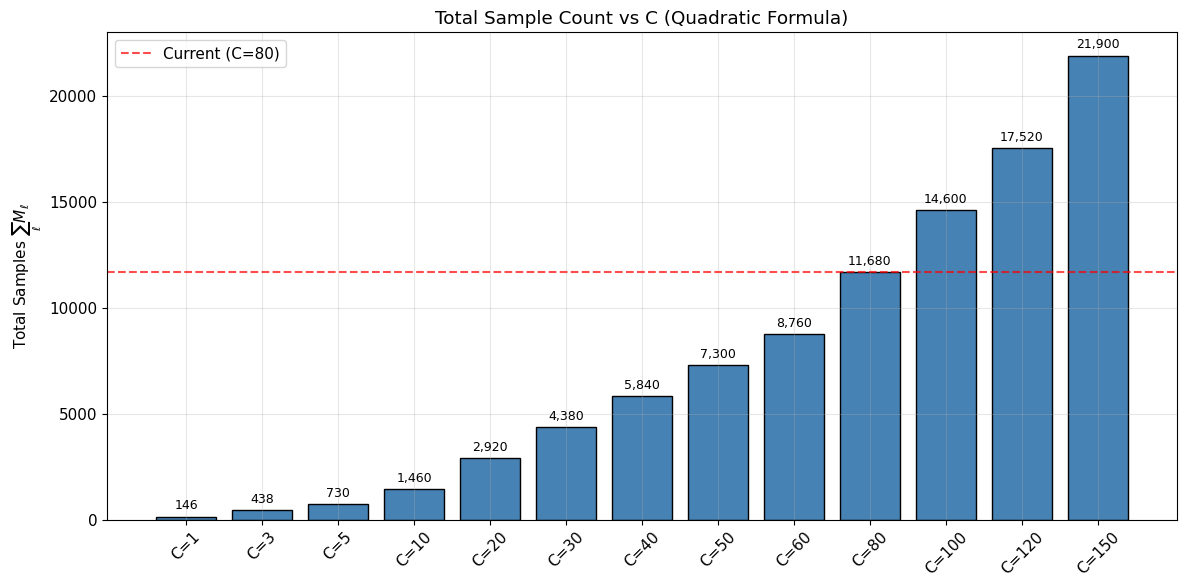

In [41]:
# Visualise sample counts
fig, ax = plt.subplots(figsize=(12, 6))

totals = [df_C_samples[df_C_samples['Strategy'] == f'C={C}']['Total'].values[0] for C in C_values]
bars = ax.bar(range(len(C_values)), totals, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([f'C={C}' for C in C_values], rotation=45)
ax.set_ylabel('Total Samples $\\sum_\\ell M_\\ell$')
ax.set_title('Total Sample Count vs C (Quadratic Formula)')

# Add value labels
for bar, total in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f'{total:,}', ha='center', va='bottom', fontsize=9)

# Mark current implementation
ax.axhline(y=totals[C_values.index(80)], color='red', linestyle='--', 
           label='Current (C=80)', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

### Run Experiments for Each $C$ Value

For each value of $C$, we run the MLMC estimation with 10 different random seeds.

In [42]:
print(f"Running {len(C_values)} C values × {N_SEEDS} seeds = {len(C_values) * N_SEEDS} total runs")
print("This may take a while...\n")

# Storage for results
results_by_C = {C: [] for C in C_values}

for C in C_values:
    print(f"Testing C = {C}...", end=" ")
    
    for seed_idx in range(N_SEEDS):
        seed = BASE_SEED + seed_idx
        
        try:
            # Use the flexible allocation function with quadratic formula
            result = estimate_volatility_mlmc_flexible(
                params=params,
                t_grid=t_grid,
                s_grid=s_grid,
                random_seed=seed,
                use_ot=True,
                C=C,
                formula='quadratic',  # Fixed formula, varying C
                verbose=False
            )
            
            results_by_C[C].append({
                'seed': seed,
                'time': result.computation_time,
                'b_squared': result.b_squared_values.copy(),
                'coefficients': result.coefficients.copy() if result.coefficients is not None else None,
                'total_samples': result.n_samples,
                'success': True
            })
            
        except Exception as e:
            print(f"\n  Seed {seed}: FAILED - {str(e)[:50]}")
            results_by_C[C].append({
                'seed': seed,
                'time': None,
                'b_squared': None,
                'coefficients': None,
                'total_samples': None,
                'success': False
            })
    
    # Summary for this C
    successes = sum(1 for r in results_by_C[C] if r['success'])
    if successes > 0:
        mean_time = np.mean([r['time'] for r in results_by_C[C] if r['success']])
        print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s")
    else:
        print(f"Success: 0/{N_SEEDS}")

print("\n" + "="*60)
print("Part 1 experiments complete!")

Running 13 C values × 10 seeds = 130 total runs
This may take a while...

Testing C = 1... Success: 10/10, Mean time: 0.34s
Testing C = 3... Success: 10/10, Mean time: 0.33s
Testing C = 5... Success: 10/10, Mean time: 0.35s
Testing C = 10... Success: 10/10, Mean time: 0.34s
Testing C = 20... Success: 10/10, Mean time: 0.36s
Testing C = 30... Success: 10/10, Mean time: 0.38s
Testing C = 40... Success: 10/10, Mean time: 0.42s
Testing C = 50... Success: 10/10, Mean time: 0.43s
Testing C = 60... Success: 10/10, Mean time: 0.46s
Testing C = 80... Success: 10/10, Mean time: 0.50s
Testing C = 100... Success: 10/10, Mean time: 0.53s
Testing C = 120... Success: 10/10, Mean time: 0.58s
Testing C = 150... Success: 10/10, Mean time: 0.65s

Part 1 experiments complete!


### Analyse Results: Varying $C$

In [43]:
# Compute summary statistics
summary_data_C = []

for C in C_values:
    runs = results_by_C[C]
    successful_runs = [r for r in runs if r['success']]
    
    if len(successful_runs) == 0:
        total_samples = sum(compute_samples_for_formula(params.max_degree, C, 'quadratic').values())
        summary_data_C.append({
            'C': C,
            'Total Samples': total_samples,
            'Success Rate': 0,
            'Mean Time (s)': np.nan,
            'Std Time (s)': np.nan,
            'Mean b² (centre)': np.nan,
            'Std b² (centre)': np.nan,
        })
        continue
    
    times = [r['time'] for r in successful_runs]
    
    # Get b² at centre point for comparison
    t_mid_idx = len(t_grid) // 2
    s_mid_idx = len(s_grid) // 2
    b_sq_centre = [r['b_squared'][t_mid_idx, s_mid_idx] for r in successful_runs]
    
    total_samples = successful_runs[0]['total_samples']
    
    summary_data_C.append({
        'C': C,
        'Total Samples': total_samples,
        'Success Rate': len(successful_runs) / N_SEEDS,
        'Mean Time (s)': np.mean(times),
        'Std Time (s)': np.std(times),
        'Mean b² (centre)': np.mean(b_sq_centre),
        'Std b² (centre)': np.std(b_sq_centre),
    })

df_summary_C = pd.DataFrame(summary_data_C)
print("Summary of C Variation Experiments:")
print("=" * 90)
print(df_summary_C.to_string(index=False))

Summary of C Variation Experiments:
  C  Total Samples  Success Rate  Mean Time (s)  Std Time (s)  Mean b² (centre)  Std b² (centre)
  1            146           1.0       0.342322      0.011581      49071.787453        24.153361
  3            438           1.0       0.330666      0.008755      49072.896569        15.095261
  5            730           1.0       0.346463      0.015372      49071.622377        16.480266
 10           1460           1.0       0.344654      0.008368      49075.197676        14.957786
 20           2920           1.0       0.363663      0.006851      49072.929654         9.147239
 30           4380           1.0       0.382614      0.009531      49081.333228        12.121763
 40           5840           1.0       0.415762      0.009568      49078.149924        10.745874
 50           7300           1.0       0.430994      0.007217      49081.059382         7.622805
 60           8760           1.0       0.457029      0.008896      49081.843029         8.0

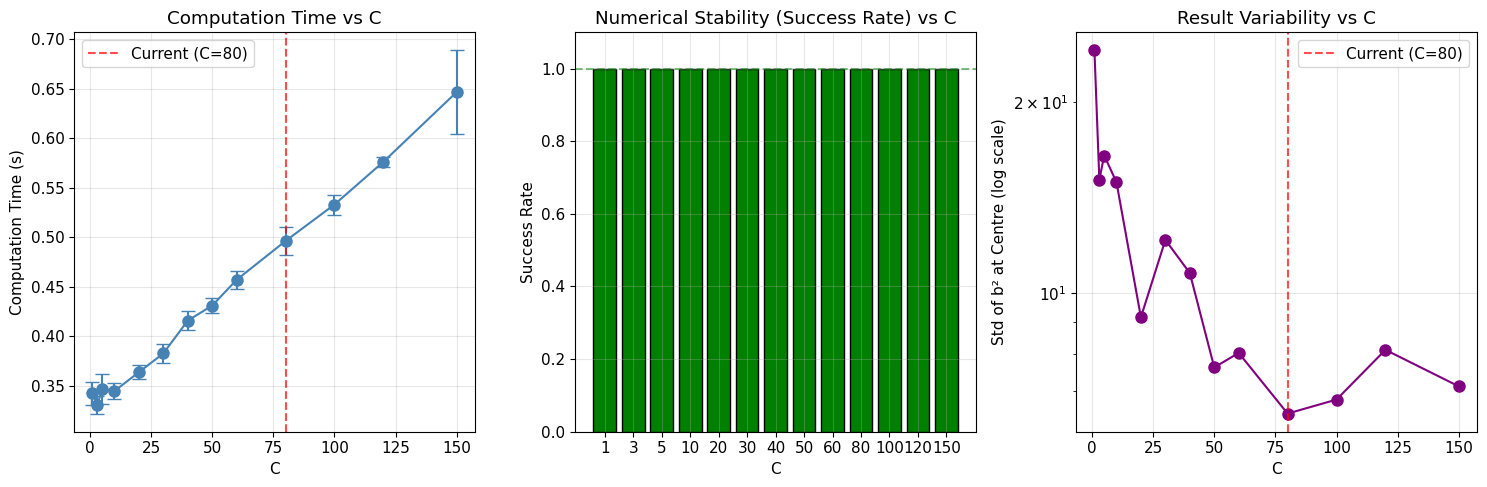

In [44]:
# Visualisation: Computation Time vs C
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Time vs C
ax1 = axes[0]
valid_mask = ~np.isnan(df_summary_C['Mean Time (s)'])
ax1.errorbar(df_summary_C.loc[valid_mask, 'C'], 
             df_summary_C.loc[valid_mask, 'Mean Time (s)'], 
             yerr=df_summary_C.loc[valid_mask, 'Std Time (s)'], 
             fmt='o-', capsize=5, color='steelblue', markersize=8)
ax1.axvline(x=80, color='red', linestyle='--', alpha=0.7, label='Current (C=80)')
ax1.set_xlabel('C')
ax1.set_ylabel('Computation Time (s)')
ax1.set_title('Computation Time vs C')
ax1.legend()

# Plot 2: Success Rate vs C
ax2 = axes[1]
colors = ['green' if sr == 1.0 else 'orange' if sr > 0.5 else 'red' 
          for sr in df_summary_C['Success Rate']]
ax2.bar(df_summary_C['C'].astype(str), df_summary_C['Success Rate'], 
        color=colors, edgecolor='black')
ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
ax2.set_xlabel('C')
ax2.set_ylabel('Success Rate')
ax2.set_title('Numerical Stability (Success Rate) vs C')
ax2.set_ylim([0, 1.1])

# Plot 3: Variance of b² at centre vs C
ax3 = axes[2]
valid_std = df_summary_C['Std b² (centre)'].replace(0, np.nan)
ax3.semilogy(df_summary_C['C'], valid_std, 'o-', color='purple', markersize=8)
ax3.axvline(x=80, color='red', linestyle='--', alpha=0.7, label='Current (C=80)')
ax3.set_xlabel('C')
ax3.set_ylabel('Std of b² at Centre (log scale)')
ax3.set_title('Result Variability vs C')
ax3.legend()

plt.tight_layout()
plt.show()

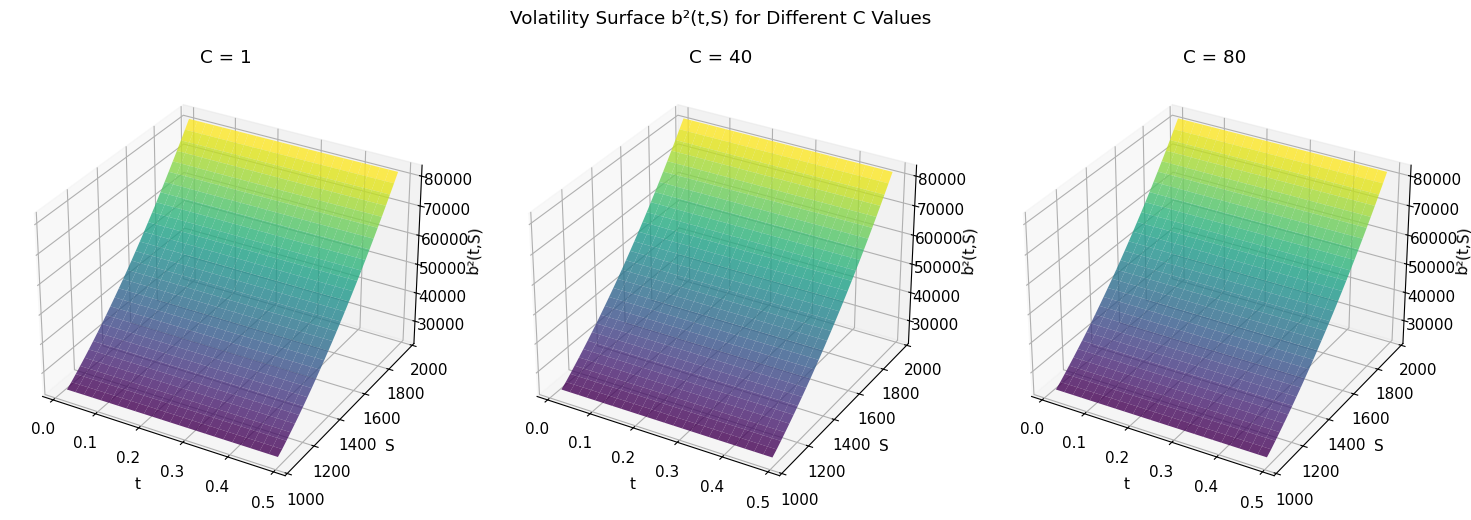

In [45]:
# Surface comparison: C=40 vs C=80 vs C=120
C_to_compare = [1, 40, 80]

fig = plt.figure(figsize=(15, 5))

for idx, C in enumerate(C_to_compare):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    successful_runs = [r for r in results_by_C[C] if r['success']]
    if len(successful_runs) > 0:
        mean_surface = np.mean([r['b_squared'] for r in successful_runs], axis=0)
        
        T_mesh, S_mesh = np.meshgrid(t_grid, s_grid, indexing='ij')
        surf = ax.plot_surface(T_mesh, S_mesh, mean_surface, cmap=cm.viridis, alpha=0.8)
        
        ax.set_xlabel('t')
        ax.set_ylabel('S')
        ax.set_zlabel('b²(t,S)')
        ax.set_title(f'C = {C}')
    else:
        ax.set_title(f'C = {C} (FAILED)')

plt.suptitle('Volatility Surface b²(t,S) for Different C Values', y=1.02)
plt.tight_layout()
plt.show()

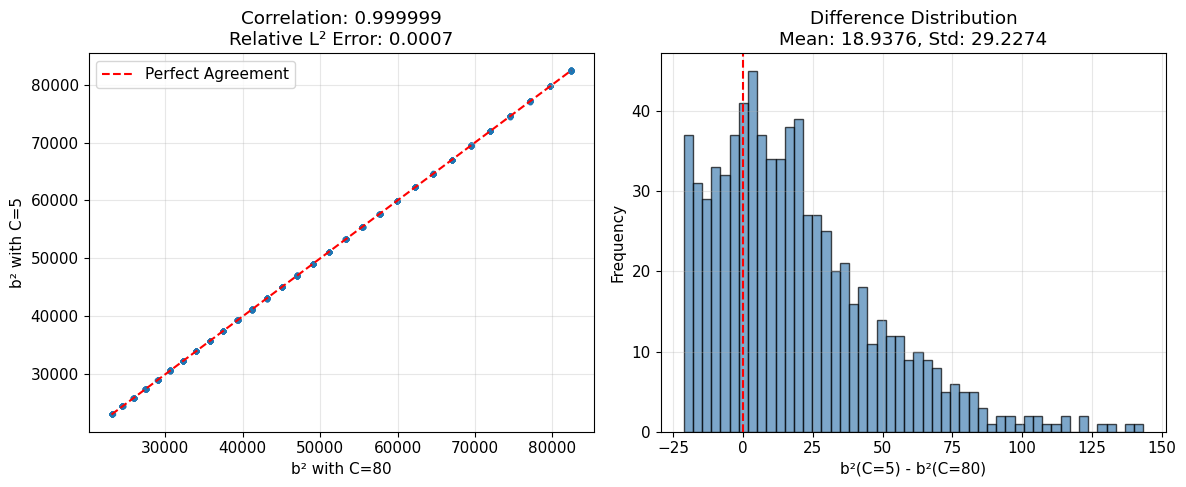

In [46]:
# Correlation plot: Compare surfaces for different C values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

C_baseline = 80
C_test = 5

successful_baseline = [r for r in results_by_C[C_baseline] if r['success']]
successful_test = [r for r in results_by_C[C_test] if r['success']]

if len(successful_baseline) > 0 and len(successful_test) > 0:
    mean_baseline = np.mean([r['b_squared'] for r in successful_baseline], axis=0).flatten()
    mean_test = np.mean([r['b_squared'] for r in successful_test], axis=0).flatten()
    
    # Scatter plot
    ax1 = axes[0]
    ax1.scatter(mean_baseline, mean_test, alpha=0.5, s=10)
    
    lims = [min(mean_baseline.min(), mean_test.min()),
            max(mean_baseline.max(), mean_test.max())]
    ax1.plot(lims, lims, 'r--', label='Perfect Agreement')
    
    corr = np.corrcoef(mean_baseline, mean_test)[0, 1]
    l2_err = compute_l2_error(mean_test.reshape(-1), mean_baseline.reshape(-1))
    ax1.set_xlabel(f'b² with C={C_baseline}')
    ax1.set_ylabel(f'b² with C={C_test}')
    ax1.set_title(f'Correlation: {corr:.6f}\nRelative L² Error: {l2_err:.4f}')
    ax1.legend()
    
    # Difference histogram
    ax2 = axes[1]
    diff = mean_test - mean_baseline
    ax2.hist(diff, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_xlabel(f'b²(C={C_test}) - b²(C={C_baseline})')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Difference Distribution\nMean: {np.mean(diff):.4f}, Std: {np.std(diff):.4f}')
else:
    print(f"Cannot compare: C={C_baseline} has {len(successful_baseline)} successes, "
          f"C={C_test} has {len(successful_test)} successes")

plt.tight_layout()
plt.show()

### Part 1 Conclusions

Based on the above analysis:

- **Minimum stable C:** 10
- **Recommended C:** Not sure
- **Potential speedup vs C=80:** High

---

# Part 2: TRUE Comparison of Different Allocation Formulas

Now we compare fundamentally different formulas for $M_\ell$ using **properly modified MLMC functions**.

| Strategy | Formula | Theoretical Basis |
|----------|---------|-------------------|
| Quadratic | $M_\ell = C \cdot m^2$ | Conservative (our current) |
| Log | $M_\ell = C \cdot m \log(m+1)$ | Cohen-Migliorati optimal |
| Sqrt | $M_\ell = C \cdot m^{1.5}$ | Intermediate |
| Linear | $M_\ell = C \cdot m$ | Minimum for uniqueness |
| Log² | $M_\ell = C \cdot m \log^2(m+1)$ | Extra conservative relative to log |

In [47]:
# Define formulas to test
formulas_to_test = ['quadratic', 'log', 'sqrt', 'linear', 'log_squared']
C_fixed = 5  # Keep C fixed to isolate formula effect

print(f"Testing {len(formulas_to_test)} different allocation formulas with C={C_fixed}")
print("\nSample counts by formula:")
print("=" * 90)

formula_strategies = {
    'Quadratic (C·m²)': (C_fixed, 'quadratic'),
    'Log (C·m·log(m+1))': (C_fixed, 'log'),
    'Sqrt (C·m^1.5)': (C_fixed, 'sqrt'),
    'Linear (C·m)': (C_fixed, 'linear'),
    'Log² (C·m·log²(m+1))': (C_fixed, 'log_squared'),
}

df_formula_samples = format_samples_table(params.max_degree, formula_strategies)
print(df_formula_samples.to_string(index=False))

Testing 5 different allocation formulas with C=5

Sample counts by formula:
            Strategy  C     Formula  Level 0  Level 1  Level 2  Level 3  Total
    Quadratic (C·m²)  5   quadratic      500      180       45        5    730
  Log (C·m·log(m+1))  5         log      119       58       20        5    202
      Sqrt (C·m^1.5)  5        sqrt      158       73       25        5    261
        Linear (C·m)  5      linear       50       30       15        5    100
Log² (C·m·log²(m+1))  5 log_squared      287      113       28        5    433


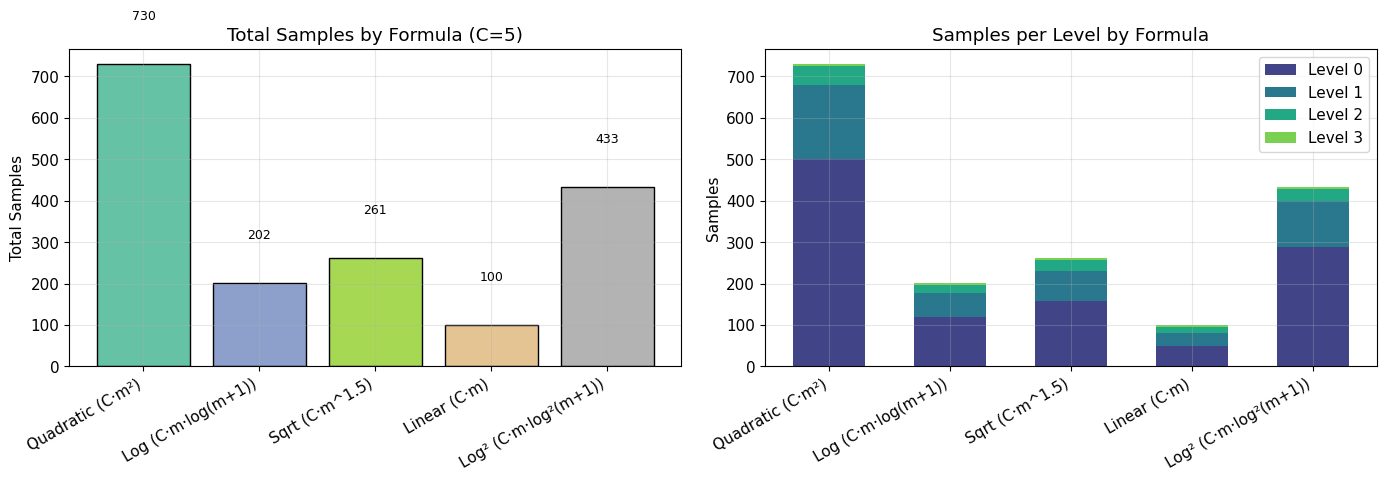

In [48]:
# Visualise sample counts by formula
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: total samples
ax1 = axes[0]
formula_names = list(formula_strategies.keys())
totals = df_formula_samples['Total'].values
colors = plt.cm.Set2(np.linspace(0, 1, len(formula_names)))
bars = ax1.bar(range(len(formula_names)), totals, color=colors, edgecolor='black')
ax1.set_xticks(range(len(formula_names)))
ax1.set_xticklabels(formula_names, rotation=30, ha='right')
ax1.set_ylabel('Total Samples')
ax1.set_title(f'Total Samples by Formula (C={C_fixed})')

for bar, total in zip(bars, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{total:,}', ha='center', va='bottom', fontsize=9)

# Stacked bar: samples per level
ax2 = axes[1]
x = np.arange(len(formula_names))
width = 0.6

bottom = np.zeros(len(formula_names))
level_colors = plt.cm.viridis(np.linspace(0.2, 0.8, params.max_degree + 1))

for l in range(params.max_degree + 1):
    values = df_formula_samples[f'Level {l}'].values
    ax2.bar(x, values, width, bottom=bottom, label=f'Level {l}', color=level_colors[l])
    bottom += values

ax2.set_xticks(x)
ax2.set_xticklabels(formula_names, rotation=30, ha='right')
ax2.set_ylabel('Samples')
ax2.set_title('Samples per Level by Formula')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Run TRUE Formula Comparison Experiments

Using the modified MLMC functions with proper sample allocation for each formula.

In [49]:
print(f"Running TRUE formula comparison: {len(formulas_to_test)} formulas × {N_SEEDS} seeds")
print(f"= {len(formulas_to_test) * N_SEEDS} total runs\n")

results_by_formula = {f: [] for f in formulas_to_test}

for formula in formulas_to_test:
    samples_info = compute_samples_for_formula(params.max_degree, C_fixed, formula)
    total_samples = sum(samples_info.values())
    print(f"Testing formula: {formula} ({total_samples:,} total samples)...", end=" ")
    
    for seed_idx in range(N_SEEDS):
        seed = BASE_SEED + seed_idx
        
        try:
            # Use the TRUE flexible allocation function
            result = estimate_volatility_mlmc_flexible(
                params=params,
                t_grid=t_grid,
                s_grid=s_grid,
                random_seed=seed,
                use_ot=True,
                C=C_fixed,
                formula=formula,  # TRUE formula, not approximation!
                verbose=False
            )
            
            results_by_formula[formula].append({
                'seed': seed,
                'time': result.computation_time,
                'b_squared': result.b_squared_values.copy(),
                'coefficients': result.coefficients.copy() if result.coefficients is not None else None,
                'total_samples': result.n_samples,
                'samples_per_level': result.parameters.get('samples_per_level', {}),
                'success': True
            })
            
        except Exception as e:
            print(f"\n  Seed {seed}: FAILED - {str(e)[:60]}")
            results_by_formula[formula].append({
                'seed': seed,
                'time': None,
                'b_squared': None,
                'coefficients': None,
                'total_samples': None,
                'samples_per_level': None,
                'success': False
            })
    
    # Summary
    successes = sum(1 for r in results_by_formula[formula] if r['success'])
    if successes > 0:
        mean_time = np.mean([r['time'] for r in results_by_formula[formula] if r['success']])
        print(f"Success: {successes}/{N_SEEDS}, Mean time: {mean_time:.2f}s")
    else:
        print(f"Success: 0/{N_SEEDS}")

print("\n" + "="*60)
print("Part 2 experiments complete!")

Running TRUE formula comparison: 5 formulas × 10 seeds
= 50 total runs

Testing formula: quadratic (730 total samples)... Success: 10/10, Mean time: 0.36s
Testing formula: log (202 total samples)... Success: 10/10, Mean time: 0.33s
Testing formula: sqrt (261 total samples)... Success: 10/10, Mean time: 0.33s
Testing formula: linear (100 total samples)... Success: 10/10, Mean time: 0.33s
Testing formula: log_squared (433 total samples)... Success: 10/10, Mean time: 0.33s

Part 2 experiments complete!


### Analyse Formula Comparison Results

In [50]:
# Compute summary statistics for each formula
summary_formula = []

for formula in formulas_to_test:
    runs = results_by_formula[formula]
    successful = [r for r in runs if r['success']]
    
    if len(successful) == 0:
        total_samples = sum(compute_samples_for_formula(params.max_degree, C_fixed, formula).values())
        summary_formula.append({
            'Formula': formula,
            'Total Samples': total_samples,
            'Success Rate': 0,
            'Mean Time (s)': np.nan,
            'Std Time (s)': np.nan,
            'Mean Std(b²)': np.nan,
            'Max Std(b²)': np.nan,
        })
        continue
    
    times = [r['time'] for r in successful]
    total_samples = successful[0]['total_samples']
    
    # Compute variance across runs
    all_surfaces = np.array([r['b_squared'] for r in successful])
    mean_surface = np.mean(all_surfaces, axis=0)
    std_surface = np.std(all_surfaces, axis=0)
    
    summary_formula.append({
        'Formula': formula,
        'Total Samples': total_samples,
        'Success Rate': len(successful) / N_SEEDS,
        'Mean Time (s)': np.mean(times),
        'Std Time (s)': np.std(times),
        'Mean Std(b²)': np.mean(std_surface),
        'Max Std(b²)': np.max(std_surface),
    })

df_summary_formula = pd.DataFrame(summary_formula)
print("TRUE Formula Comparison Summary:")
print("=" * 90)
print(df_summary_formula.to_string(index=False))

TRUE Formula Comparison Summary:
    Formula  Total Samples  Success Rate  Mean Time (s)  Std Time (s)  Mean Std(b²)  Max Std(b²)
  quadratic            730           1.0       0.355898      0.017246     77.686131   409.884379
        log            202           1.0       0.334915      0.014924    155.214168   813.382328
       sqrt            261           1.0       0.331022      0.011658    134.363359   725.659474
     linear            100           1.0       0.329638      0.011480    253.028395  1394.853615
log_squared            433           1.0       0.334062      0.016969    104.492973   512.833585


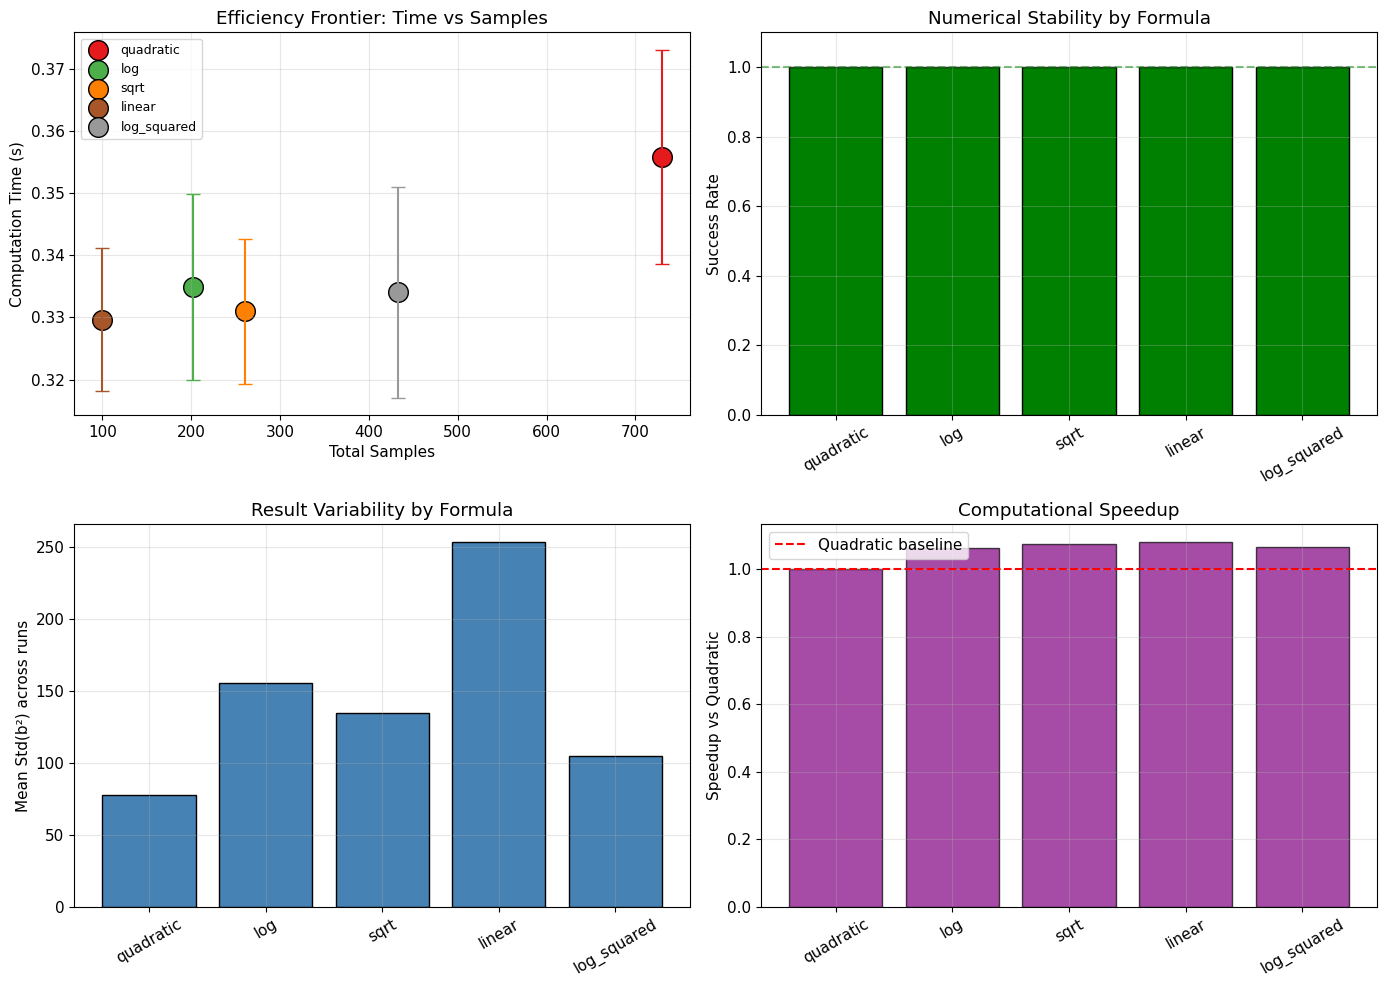

In [51]:
# Visualisation: Formula comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter to successful formulas
df_valid = df_summary_formula[df_summary_formula['Success Rate'] > 0]

# Plot 1: Time vs Total Samples (efficiency frontier)
ax1 = axes[0, 0]
colors_scatter = plt.cm.Set1(np.linspace(0, 1, len(df_valid)))
for i, (idx, row) in enumerate(df_valid.iterrows()):
    ax1.scatter(row['Total Samples'], row['Mean Time (s)'], 
               s=200, label=row['Formula'], color=colors_scatter[i], marker='o', edgecolor='black')
    ax1.errorbar(row['Total Samples'], row['Mean Time (s)'],
                yerr=row['Std Time (s)'], fmt='none', capsize=5, color=colors_scatter[i])

ax1.set_xlabel('Total Samples')
ax1.set_ylabel('Computation Time (s)')
ax1.set_title('Efficiency Frontier: Time vs Samples')
ax1.legend(fontsize=9)

# Plot 2: Success Rate by Formula
ax2 = axes[0, 1]
colors_bar = ['green' if sr == 1.0 else 'orange' if sr > 0.5 else 'red' 
              for sr in df_summary_formula['Success Rate']]
ax2.bar(df_summary_formula['Formula'], df_summary_formula['Success Rate'], 
        color=colors_bar, edgecolor='black')
ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
ax2.set_ylabel('Success Rate')
ax2.set_title('Numerical Stability by Formula')
ax2.set_ylim([0, 1.1])
ax2.tick_params(axis='x', rotation=30)

# Plot 3: Variability by Formula
ax3 = axes[1, 0]
valid_mean_std = df_summary_formula['Mean Std(b²)'].replace(0, np.nan)
ax3.bar(df_summary_formula['Formula'], valid_mean_std, 
        color='steelblue', edgecolor='black')
ax3.set_ylabel('Mean Std(b²) across runs')
ax3.set_title('Result Variability by Formula')
ax3.tick_params(axis='x', rotation=30)

# Plot 4: Speedup relative to quadratic
ax4 = axes[1, 1]
if 'quadratic' in df_valid['Formula'].values:
    quad_time = df_valid[df_valid['Formula'] == 'quadratic']['Mean Time (s)'].values[0]
    speedups = quad_time / df_valid['Mean Time (s)']
    ax4.bar(df_valid['Formula'], speedups, color='purple', edgecolor='black', alpha=0.7)
    ax4.axhline(y=1.0, color='red', linestyle='--', label='Quadratic baseline')
    ax4.set_ylabel('Speedup vs Quadratic')
    ax4.set_title('Computational Speedup')
    ax4.legend()
ax4.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

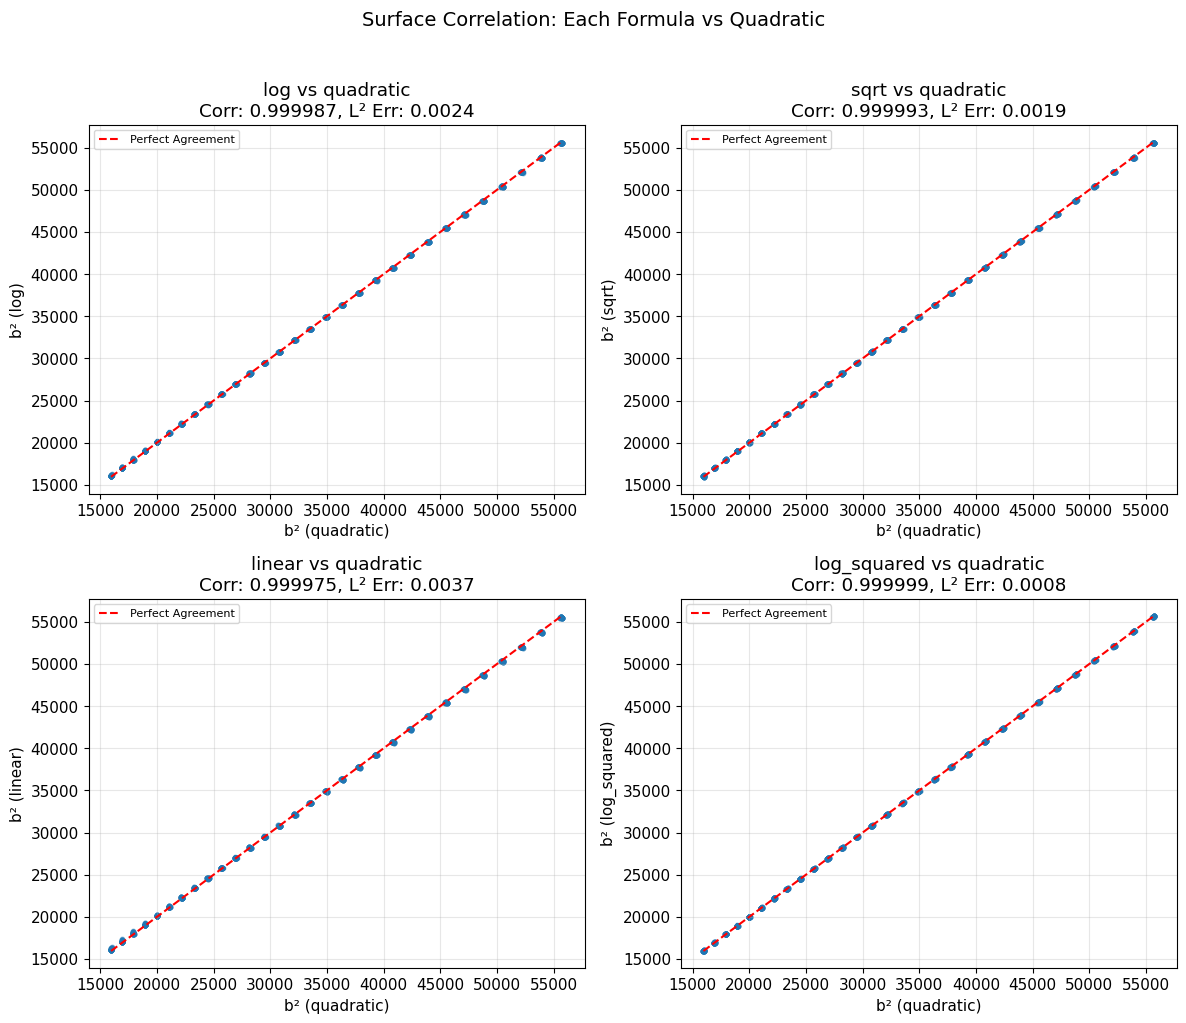

In [29]:
# Cross-formula correlation analysis
# Compare each formula against quadratic (baseline)

baseline_formula = 'quadratic'
baseline_runs = [r for r in results_by_formula[baseline_formula] if r['success']]

if len(baseline_runs) > 0:
    mean_baseline = np.mean([r['b_squared'] for r in baseline_runs], axis=0)
    
    other_formulas = [f for f in formulas_to_test if f != baseline_formula]
    n_others = len(other_formulas)
    
    fig, axes = plt.subplots(2, (n_others + 1) // 2, figsize=(6 * ((n_others + 1) // 2), 10))
    axes = axes.flatten()
    
    for idx, formula in enumerate(other_formulas):
        ax = axes[idx]
        
        formula_runs = [r for r in results_by_formula[formula] if r['success']]
        
        if len(formula_runs) > 0:
            mean_formula = np.mean([r['b_squared'] for r in formula_runs], axis=0)
            
            ax.scatter(mean_baseline.flatten(), mean_formula.flatten(), alpha=0.5, s=10)
            
            lims = [min(mean_baseline.min(), mean_formula.min()),
                    max(mean_baseline.max(), mean_formula.max())]
            ax.plot(lims, lims, 'r--', label='Perfect Agreement')
            
            corr = np.corrcoef(mean_baseline.flatten(), mean_formula.flatten())[0, 1]
            l2_err = compute_l2_error(mean_formula, mean_baseline)
            
            ax.set_xlabel(f'b² ({baseline_formula})')
            ax.set_ylabel(f'b² ({formula})')
            ax.set_title(f'{formula} vs {baseline_formula}\nCorr: {corr:.6f}, L² Err: {l2_err:.4f}')
            ax.legend(fontsize=8)
        else:
            ax.set_title(f'{formula} (FAILED)')
            ax.text(0.5, 0.5, 'No successful runs', ha='center', va='center', transform=ax.transAxes)
    
    # Hide unused subplots
    for idx in range(len(other_formulas), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'Surface Correlation: Each Formula vs {baseline_formula.capitalize()}', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"No successful runs for baseline formula '{baseline_formula}'")

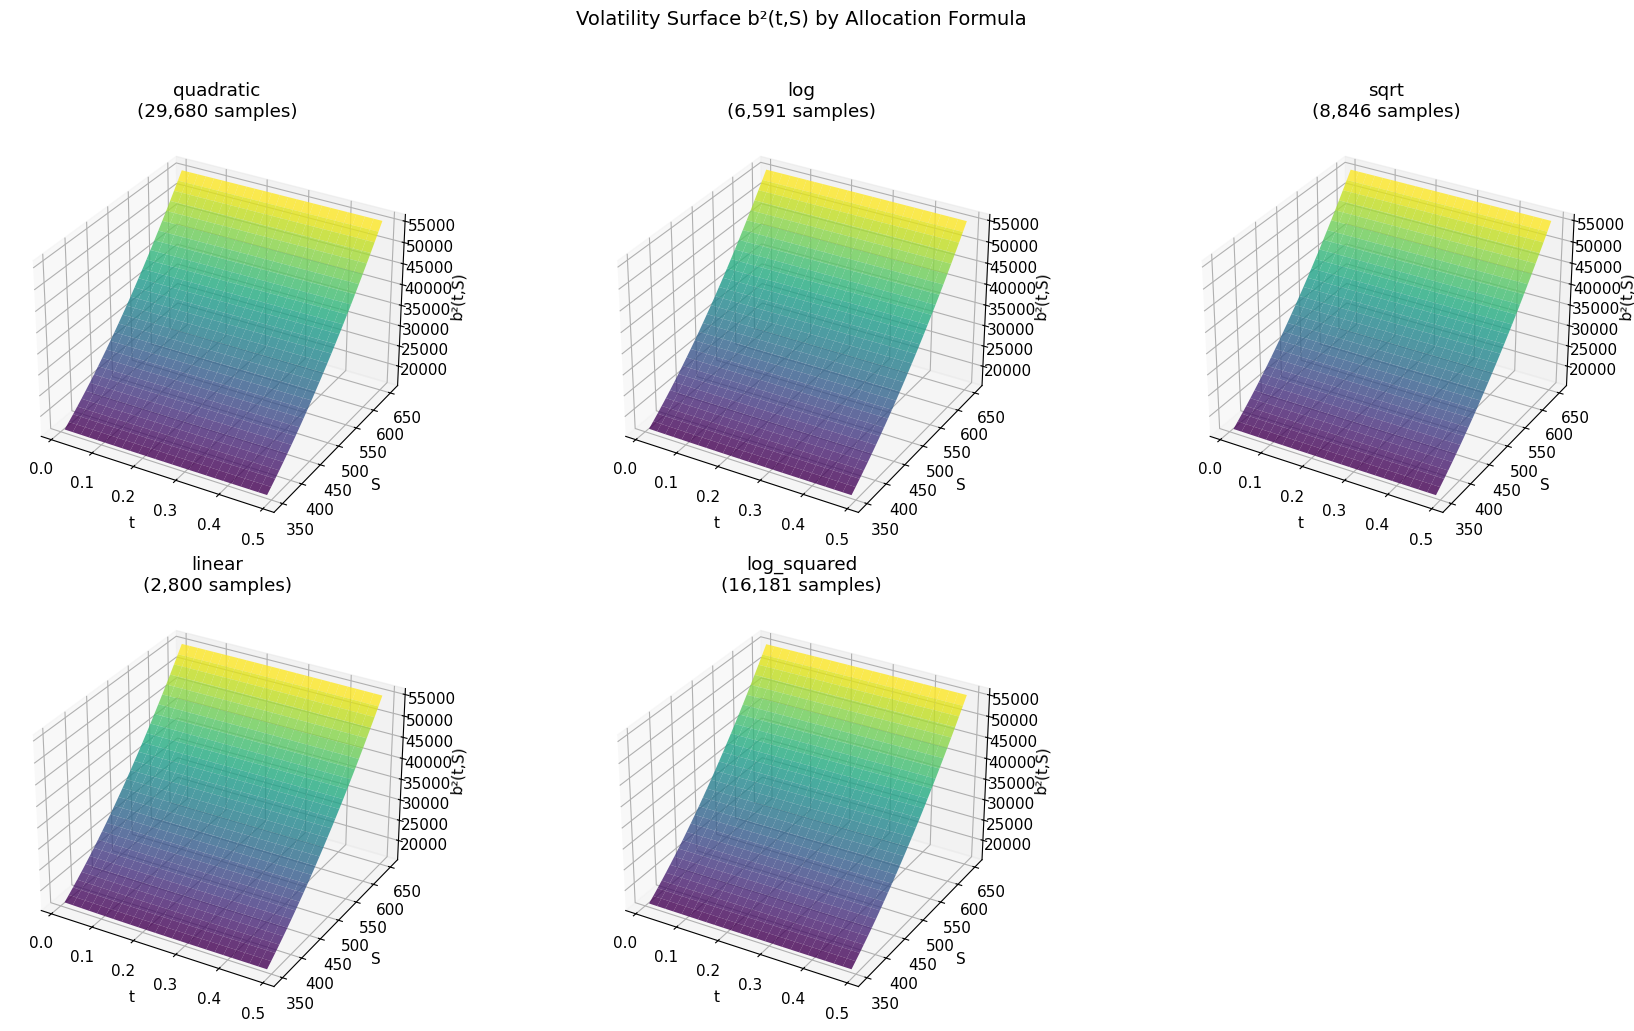

In [30]:
# Side-by-side 3D surface comparison
successful_formulas = [f for f in formulas_to_test 
                       if any(r['success'] for r in results_by_formula[f])]

n_cols = min(3, len(successful_formulas))
n_rows = (len(successful_formulas) + n_cols - 1) // n_cols

fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))

for idx, formula in enumerate(successful_formulas):
    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
    
    successful = [r for r in results_by_formula[formula] if r['success']]
    mean_surface = np.mean([r['b_squared'] for r in successful], axis=0)
    total_samples = successful[0]['total_samples']
    
    T_mesh, S_mesh = np.meshgrid(t_grid, s_grid, indexing='ij')
    surf = ax.plot_surface(T_mesh, S_mesh, mean_surface, cmap=cm.viridis, alpha=0.8)
    
    ax.set_xlabel('t')
    ax.set_ylabel('S')
    ax.set_zlabel('b²(t,S)')
    ax.set_title(f'{formula}\n({total_samples:,} samples)')

plt.suptitle('Volatility Surface b²(t,S) by Allocation Formula', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---

## Final Summary and Recommendations

In [31]:
print("="*90)
print("FINAL SUMMARY")
print("="*90)

print("\n--- Part 1: Varying C in Quadratic Formula ---")
print(df_summary_C[['C', 'Total Samples', 'Success Rate', 'Mean Time (s)', 'Std b² (centre)']].to_string(index=False))

print("\n--- Part 2: TRUE Formula Comparison ---")
print(df_summary_formula.to_string(index=False))

print("\n" + "="*90)
print("KEY FINDINGS")
print("="*90)

# Find minimum stable C
stable_C_mask = df_summary_C['Success Rate'] == 1.0
if stable_C_mask.any():
    stable_C = df_summary_C.loc[stable_C_mask, 'C'].min()
    print(f"\n1. Minimum C with 100% success rate (quadratic): C = {stable_C}")
    
    if stable_C < 80:
        time_80 = df_summary_C[df_summary_C['C'] == 80]['Mean Time (s)'].values[0]
        time_min = df_summary_C[df_summary_C['C'] == stable_C]['Mean Time (s)'].values[0]
        speedup = time_80 / time_min
        print(f"   Potential speedup from C=80 to C={stable_C}: {speedup:.2f}x")
else:
    print("\n1. No C value achieved 100% success rate")

# Best formula analysis
stable_formulas = df_summary_formula[df_summary_formula['Success Rate'] == 1.0]
if len(stable_formulas) > 0:
    fastest = stable_formulas.loc[stable_formulas['Mean Time (s)'].idxmin()]
    print(f"\n2. Fastest stable formula: {fastest['Formula']}")
    print(f"   Total samples: {fastest['Total Samples']:,}")
    print(f"   Mean time: {fastest['Mean Time (s)']:.2f}s")
    
    if fastest['Formula'] != 'quadratic':
        quad_time = df_summary_formula[df_summary_formula['Formula'] == 'quadratic']['Mean Time (s)'].values
        if len(quad_time) > 0 and not np.isnan(quad_time[0]):
            speedup = quad_time[0] / fastest['Mean Time (s)']
            print(f"   Speedup vs quadratic: {speedup:.2f}x")

print("\n" + "="*90)

FINAL SUMMARY

--- Part 1: Varying C in Quadratic Formula ---
  C  Total Samples  Success Rate  Mean Time (s)  Std b² (centre)
  1            371           1.0       0.388438        44.067251
  3           1113           1.0       0.401200        48.214914
  5           1855           1.0       0.413691        35.884587
 10           3710           1.0       0.440976        13.886729
 20           7420           1.0       0.516395        43.687207
 30          11130           1.0       0.586901        33.604816
 40          14840           1.0       0.668163        31.172661
 50          18550           1.0       0.744442        42.449452
 60          22260           1.0       0.870140        48.626731
 80          29680           1.0       0.970760        32.622469
100          37100           1.0       1.098407        39.913473
120          44520           1.0       1.251627        29.368476
150          55650           1.0       1.537534        25.067130

--- Part 2: TRUE Formula Co

## Conclusions

TO BE FILLED IN. I WANT TO AT LEAST SEE SOME COLLAPSE BEFORE I DO

### Part 1: Effect of C

- **Minimum stable C:** _____
- **Recommended C:** _____
- **Potential speedup:** _____

### Part 2: TRUE Formula Comparison

- **Quadratic stability:** _____
- **Log formula stability:** _____
- **Sqrt formula stability:** _____
- **Linear formula stability:** _____
- **Best trade-off (stability + speed):** _____

### Recommendations

1. If _____ formula is stable, consider switching from quadratic
2. Potential computational savings: _____
3. Further investigation needed: _____